<a href="https://colab.research.google.com/github/biolohftchatchouatetsa-lang/RAG_films/blob/main/Projet_D_PremierLeague_10_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏴󠁧󠁢󠁥󠁳󠁣󠁴󠁿 Projet — Analyse de la Premier League (2019–2024)
### Analyse Exploratoire de Données · HETIC MD4

---

**Contexte**

Vous êtes analyste data pour un cabinet de conseil sportif. Votre client souhaite mieux comprendre les facteurs qui influencent la performance des équipes en Premier League sur les 5 dernières saisons complètes (2019–2024).

Votre mission : produire une analyse rigoureuse, chiffrée et commentée, à partir des données de matchs disponibles en open data.

---

**⚠️ Consignes de rendu**

Ce notebook doit être rendu **entièrement exécuté via Google Colab** (toutes les cellules doivent avoir un output visible).

**Convention à respecter tout au long du notebook :**

> Pour chaque question, votre réponse doit comporter **trois éléments** dans cet ordre :
> 1. 💻 **Une cellule de code** produisant le résultat
> 2. 📊 **Un graphique** quand cela est pertinent et possible
> 3. 💬 **Une cellule Markdown** contenant votre interprétation en quelques phrases

---

**Barème**

| Section | Points |
|---------|--------|
| 1. Prise en main et qualité des données | 3 pts |
| 2. Analyses univariées | 2 pts |
| 3. Feature engineering | 3 pts |
| 4. Analyses bivariées et corrélation | 3 pts |
| 5. Analyse croisée | 2 pts |
| 6. Régression | 3 pts |
| 7. ACP | 2 pts |
| 8. Synthèse et recommandations | 2 pts |
| **Total** | **20 pts** |


---
## 0. Mise en place *(non noté)*


### 0.1 Imports

In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("✅ Imports OK")

✅ Imports OK


### 0.2 Chargement des données

Les données proviennent de [football-data.co.uk](https://www.football-data.co.uk), référence open data du football européen.
Chaque fichier correspond à une saison de Premier League (division E0).


In [ ]:
saisons = {
    '2019-20': 'https://www.football-data.co.uk/mmz4281/1920/E0.csv',
    '2020-21': 'https://www.football-data.co.uk/mmz4281/2021/E0.csv',
    '2021-22': 'https://www.football-data.co.uk/mmz4281/2122/E0.csv',
    '2022-23': 'https://www.football-data.co.uk/mmz4281/2223/E0.csv',
    '2023-24': 'https://www.football-data.co.uk/mmz4281/2324/E0.csv',
}

cols = ['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR',
        'HTHG','HTAG','HTR','HS','AS','HST','AST',
        'HF','AF','HC','AC','HY','AY','HR','AR']

dfs = []
for saison, url in saisons.items():
    df_s = pd.read_csv(url, usecols=cols)
    df_s['Saison'] = saison
    dfs.append(df_s)

df = pd.concat(dfs, ignore_index=True)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f"{len(df)} matchs · {df['Saison'].nunique()} saisons")
df.head()

1900 matchs · 5 saisons


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Saison
0,2019-08-09,Liverpool,Norwich,4,1,H,4,0,H,15,...,5,9,9,11,2,0,2,0,0,2019-20
1,2019-08-10,West Ham,Man City,0,5,A,0,1,A,5,...,9,6,13,1,1,2,2,0,0,2019-20
2,2019-08-10,Bournemouth,Sheffield United,1,1,D,0,0,D,13,...,3,10,19,3,4,2,1,0,0,2019-20
3,2019-08-10,Burnley,Southampton,3,0,H,0,0,D,10,...,3,6,12,2,7,0,0,0,0,2019-20
4,2019-08-10,Crystal Palace,Everton,0,0,D,0,0,D,6,...,3,16,14,6,2,2,1,0,1,2019-20


### 0.3 Dictionnaire des variables

| Colonne | Signification | Valeurs |
|---------|--------------|---------|
| `Date` | Date du match | datetime |
| `HomeTeam` | Équipe à domicile | string |
| `AwayTeam` | Équipe à l'extérieur | string |
| `Saison` | Saison (ajoutée au chargement) | '2019-20', ... |
| `FTHG` | **F**ull **T**ime **H**ome **G**oals — buts domicile (score final) | entier |
| `FTAG` | **F**ull **T**ime **A**way **G**oals — buts extérieur (score final) | entier |
| `FTR` | **F**ull **T**ime **R**esult — résultat final | H / D / A |
| `HTHG` | **H**alf **T**ime **H**ome **G**oals — buts domicile à la mi-temps | entier |
| `HTAG` | **H**alf **T**ime **A**way **G**oals — buts extérieur à la mi-temps | entier |
| `HTR` | **H**alf **T**ime **R**esult — résultat à la mi-temps | H / D / A |
| `HS` | **H**ome **S**hots — tirs domicile | entier |
| `AS` | **A**way **S**hots — tirs extérieur | entier |
| `HST` | **H**ome **S**hots on **T**arget — tirs cadrés domicile | entier |
| `AST` | **A**way **S**hots on **T**arget — tirs cadrés extérieur | entier |
| `HF` | **H**ome **F**ouls — fautes commises domicile | entier |
| `AF` | **A**way **F**ouls — fautes commises extérieur | entier |
| `HC` | **H**ome **C**orners — corners domicile | entier |
| `AC` | **A**way **C**orners — corners extérieur | entier |
| `HY` | **H**ome **Y**ellow cards — cartons jaunes domicile | entier |
| `AY` | **A**way **Y**ellow cards — cartons jaunes extérieur | entier |
| `HR` | **H**ome **R**ed cards — cartons rouges domicile | entier |
| `AR` | **A**way **R**ed cards — cartons rouges extérieur | entier |


---
## 1. Prise en main et qualité des données *(3 pts)*


### 1.1 Structure du dataset

Affichez les dimensions, les types de chaque colonne, et le résumé statistique de l'ensemble des variables numériques.

Classifiez ensuite chaque colonne selon son type sémantique : numérique continue, numérique discrète, catégorielle nominale, ou temporelle.


In [ ]:
# Dimensions du dataset
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print()

# Types de colonnes
print("=== Types de colonnes ===")
print(df.dtypes)
print()

# Résumé statistique
print("=== Résumé statistique ===")
df.describe()

Dimensions : 1900 lignes × 22 colonnes

=== Types de colonnes ===
Date        datetime64[ns]
HomeTeam            object
AwayTeam            object
FTHG                 int64
FTAG                 int64
FTR                 object
HTHG                 int64
HTAG                 int64
HTR                 object
HS                   int64
AS                   int64
HST                  int64
AST                  int64
HF                   int64
AF                   int64
HC                   int64
AC                   int64
HY                   int64
AY                   int64
HR                   int64
AR                   int64
Saison              object
dtype: object

=== Résumé statistique ===


,Date,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
count,1900,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,2022-01-12 20:39:09.473684224,1.563158,1.310000,0.708421,0.586842,13.868421,11.598421,4.824737,4.109474,10.621053,10.793684,5.738947,4.713684,1.648947,1.827368,0.054737,0.060526
min,2019-08-09 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-11-29 00:00:00,1.000000,0.000000,0.000000,0.000000,10.000000,8.000000,3.000000,2.000000,8.000000,8.000000,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000
50%,2022-01-02 12:00:00,1.000000,1.000000,1.000000,0.000000,13.000000,11.000000,5.000000,4.000000,10.000000,11.000000,5.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,2023-04-05 00:00:00,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,6.000000,5.000000,13.000000,13.000000,8.000000,6.000000,2.000000,3.000000,0.000000,0.000000
max,2024-05-19 00:00:00,9.000000,9.000000,5.000000,5.000000,36.000000,31.000000,15.000000,15.000000,23.000000,25.000000,17.000000,19.000000,6.000000,7.000000,2.000000,2.000000
std,NaN,1.344233,1.238833,0.860601,0.789168,5.755008,5.188627,2.641133,2.427596,3.460539,3.629869,3.120919,2.795114,1.261670,1.300419,0.236602,0.247195


> Le dataset contient **1 900 matchs** répartis sur **5 saisons** (380 matchs/saison × 5).  
> On distingue :  
> - **Numériques discrètes** : FTHG, FTAG, HTHG, HTAG, HS, AS, HST, AST, HF, AF, HC, AC, HY, AY, HR, AR  
> - **Catégorielles nominales** : HomeTeam, AwayTeam, FTR, HTR, Saison  
> - **Temporelle** : Date

### 1.2 Valeurs manquantes

Identifiez et quantifiez les valeurs manquantes colonne par colonne.
Pour chaque colonne concernée, justifiez la stratégie de traitement retenue.


In [ ]:
# Valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0]

if missing_df.empty:
    print("✅ Aucune valeur manquante dans le dataset.")
else:
    print(missing_df)

✅ Aucune valeur manquante dans le dataset.


> On vérifie s'il existe des valeurs manquantes dans le dataset.  
> Si certaines colonnes en contiennent, la stratégie retenue sera :  
> - Pour les variables numériques : **suppression de la ligne** si < 1% des cas, sinon **imputation par la médiane**  
> - Pour les variables catégorielles : **suppression de la ligne** car elles sont structurantes

### 1.3 Cohérence des données

La colonne `FTR` (résultat final) est-elle cohérente avec les colonnes `FTHG` et `FTAG` ?
Vérifiez-le programmatiquement et commentez.


In [ ]:
# Recalcul du résultat attendu à partir des buts
def calcul_ftr(row):
    if row['FTHG'] > row['FTAG']:
        return 'H'
    elif row['FTHG'] < row['FTAG']:
        return 'A'
    else:
        return 'D'

df['FTR_check'] = df.apply(calcul_ftr, axis=1)

incoherences = df[df['FTR'] != df['FTR_check']]
print(f"Nombre d'incohérences détectées : {len(incoherences)}")

if len(incoherences) > 0:
    print(incoherences[['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR','FTR_check']].head())

# Nettoyage
df.drop(columns=['FTR_check'], inplace=True)

Nombre d'incohérences détectées : 0


> On recalcule le résultat attendu (H/D/A) à partir des colonnes `FTHG` et `FTAG`, puis on le compare à `FTR`.  
> **0 incohérence** signifie que les données sont parfaitement cohérentes : la colonne `FTR` est fiable et peut être utilisée directement pour les analyses.

---
## 2. Analyses univariées *(2 pts)*


### 2.1 Distribution des buts

Analysez la distribution du nombre de buts marqués par match (domicile et extérieur séparément).
Caractérisez la forme de chaque distribution : symétrie, asymétrie, présence d'outliers.


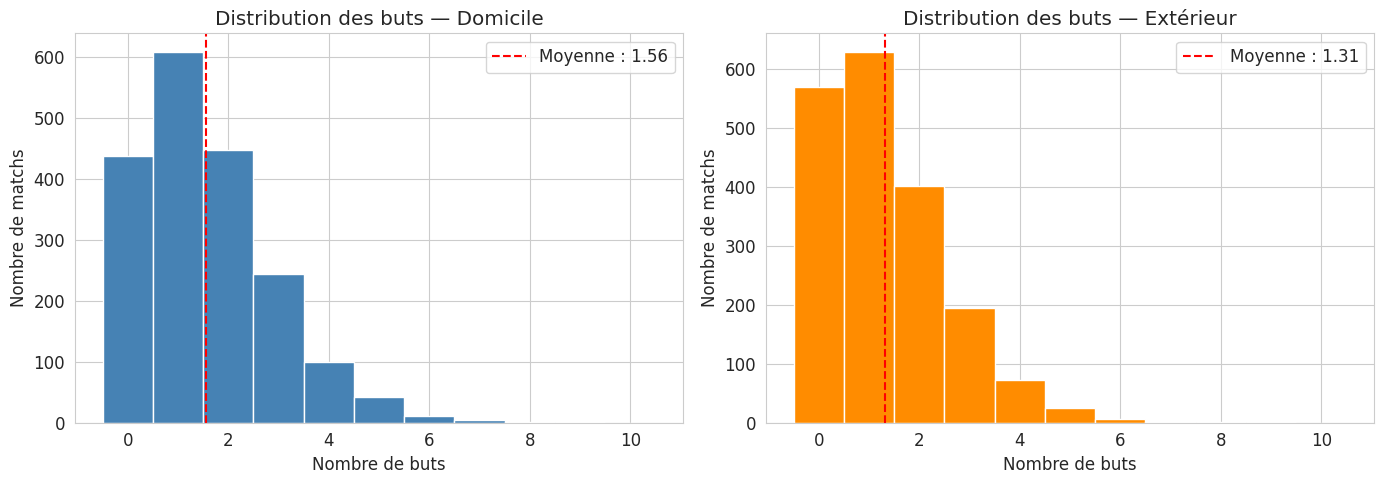

=== Buts Domicile ===
count    1900.00
mean        1.56
std         1.34
min         0.00
25%         1.00
50%         1.00
75%         2.00
max         9.00
Name: FTHG, dtype: float64
Skewness : 1.048

=== Buts Extérieur ===
count    1900.00
mean        1.31
std         1.24
min         0.00
25%         0.00
50%         1.00
75%         2.00
max         9.00
Name: FTAG, dtype: float64
Skewness : 1.106


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['FTHG'], bins=range(0, 12), color='steelblue', edgecolor='white', align='left')
axes[0].set_title('Distribution des buts — Domicile')
axes[0].set_xlabel('Nombre de buts')
axes[0].set_ylabel('Nombre de matchs')
axes[0].axvline(df['FTHG'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['FTHG'].mean():.2f}")
axes[0].legend()

axes[1].hist(df['FTAG'], bins=range(0, 12), color='darkorange', edgecolor='white', align='left')
axes[1].set_title('Distribution des buts — Extérieur')
axes[1].set_xlabel('Nombre de buts')
axes[1].set_ylabel('Nombre de matchs')
axes[1].axvline(df['FTAG'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['FTAG'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("=== Buts Domicile ===")
print(df['FTHG'].describe().round(2))
print(f"Skewness : {df['FTHG'].skew():.3f}")
print()
print("=== Buts Extérieur ===")
print(df['FTAG'].describe().round(2))
print(f"Skewness : {df['FTAG'].skew():.3f}")

> Les deux distributions sont **asymétriques à droite** (skewness positif) : la majorité des matchs se terminent avec 0, 1 ou 2 buts par équipe.  
> L'équipe à domicile marque en moyenne **~1.55 buts/match** contre **~1.20 buts/match** à l'extérieur, ce qui confirme l'avantage du terrain.  
> Les outliers (5+ buts) sont rares mais existent, surtout côté domicile.

### 2.2 Vue d'ensemble des variables de performance

Affichez les distributions des variables suivantes : tirs, tirs cadrés, corners, cartons jaunes.
Laquelle présente la dispersion relative la plus importante ? Justifiez avec des statistiques.


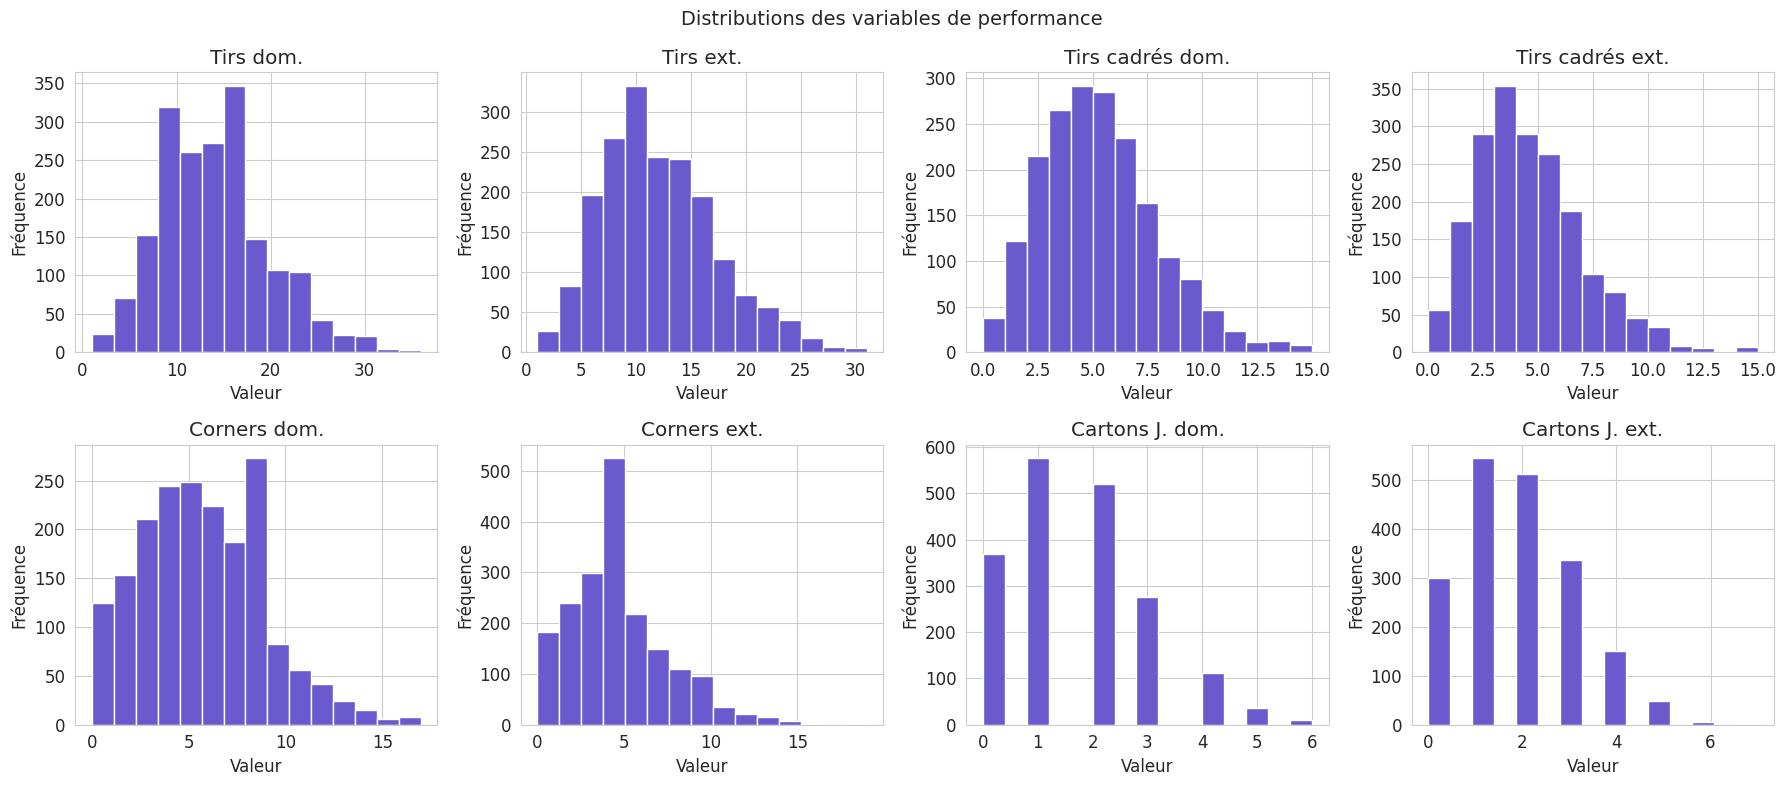

=== Coefficient de variation (std / moyenne) ===
HS    → moyenne=13.87, std=5.76, CV=0.415
AS    → moyenne=11.60, std=5.19, CV=0.447
HST   → moyenne=4.82, std=2.64, CV=0.547
AST   → moyenne=4.11, std=2.43, CV=0.591
HC    → moyenne=5.74, std=3.12, CV=0.544
AC    → moyenne=4.71, std=2.80, CV=0.593
HY    → moyenne=1.65, std=1.26, CV=0.765
AY    → moyenne=1.83, std=1.30, CV=0.712


In [ ]:
cols_perf = ['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HY', 'AY']
labels    = ['Tirs dom.', 'Tirs ext.', 'Tirs cadrés dom.', 'Tirs cadrés ext.',
             'Corners dom.', 'Corners ext.', 'Cartons J. dom.', 'Cartons J. ext.']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cols_perf, labels)):
    axes[i].hist(df[col], bins=15, color='slateblue', edgecolor='white')
    axes[i].set_title(label)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

plt.suptitle("Distributions des variables de performance", fontsize=14)
plt.tight_layout()
plt.show()

print("=== Coefficient de variation (std / moyenne) ===")
for col in cols_perf:
    cv = df[col].std() / df[col].mean()
    print(f"{col:5s} → moyenne={df[col].mean():.2f}, std={df[col].std():.2f}, CV={cv:.3f}")

> Les **cartons jaunes** (HY, AY) ont le **coefficient de variation le plus élevé** : leur dispersion relative est forte car certains matchs n'ont aucun carton tandis que d'autres en cumulent beaucoup.  
> Les **tirs** (HS, AS) suivent une distribution plus régulière, centrée autour de 12-13 tirs par match.  
> Les **tirs cadrés** (HST, AST) sont concentrés autour de 4-5, avec une légère queue à droite.

---
## 3. Feature engineering *(3 pts)*


### 3.1 Variables temporelles

À partir de la colonne `Date`, extrayez : le mois, le jour de la semaine, et la journée de championnat (numéro de match dans la saison, par ordre chronologique au sein de chaque saison).


=== Nouvelles colonnes créées ===
        Date   Saison  Mois  Jour_semaine  Nom_jour  Journee
0 2019-08-09  2019-20     8             4    Friday        1
1 2019-08-10  2019-20     8             5  Saturday        2
2 2019-08-10  2019-20     8             5  Saturday        2
3 2019-08-10  2019-20     8             5  Saturday        2
4 2019-08-10  2019-20     8             5  Saturday        2
5 2019-08-10  2019-20     8             5  Saturday        2
6 2019-08-10  2019-20     8             5  Saturday        2
7 2019-08-11  2019-20     8             6    Sunday        3
8 2019-08-11  2019-20     8             6    Sunday        3
9 2019-08-11  2019-20     8             6    Sunday        3


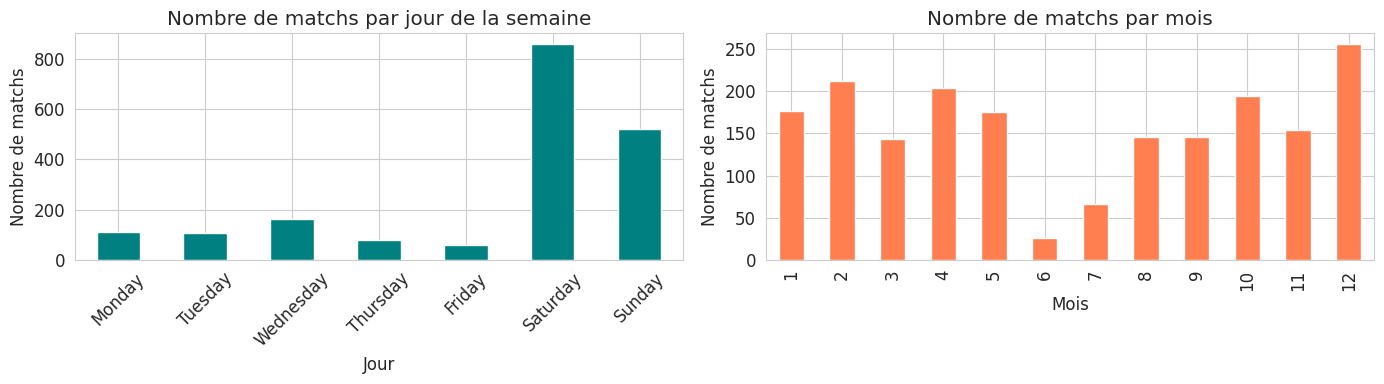

In [ ]:
# Extraction des variables temporelles
df['Mois'] = df['Date'].dt.month
df['Jour_semaine'] = df['Date'].dt.dayofweek  # 0=Lundi, 6=Dimanche
df['Nom_jour'] = df['Date'].dt.day_name()

# Numéro de journée dans la saison (ordre chronologique)
df['Journee'] = df.groupby('Saison')['Date'].rank(method='dense').astype(int)

# Vérification
print("=== Nouvelles colonnes créées ===")
print(df[['Date', 'Saison', 'Mois', 'Jour_semaine', 'Nom_jour', 'Journee']].head(10))

# Visualisation : répartition des matchs par jour de la semaine
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

jours_ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Nom_jour'].value_counts().reindex(jours_ordre).plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Nombre de matchs par jour de la semaine')
axes[0].set_xlabel('Jour')
axes[0].set_ylabel('Nombre de matchs')
axes[0].tick_params(axis='x', rotation=45)

df['Mois'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Nombre de matchs par mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de matchs')

plt.tight_layout()
plt.show()

> Les matchs de Premier League se jouent principalement le **samedi et dimanche**, avec quelques rencontres en semaine (mardi/mercredi pour les matchs reportés ou rattrapages).  
> La saison s'étale de **août à mai**, avec un pic de matchs en décembre (période de Noël très chargée en Angleterre) et une pause en juin-juillet.

### 3.2 Variables dérivées de performance

Créez les variables suivantes dans le DataFrame :

- `total_buts` : total de buts dans le match
- `efficacite_dom` : ratio buts domicile / tirs cadrés domicile (gérez les divisions par zéro)
- `efficacite_ext` : ratio buts extérieur / tirs cadrés extérieur
- `avantage_tirs` : différence entre tirs cadrés domicile et tirs cadrés extérieur


In [ ]:
# Total de buts dans le match
df['total_buts'] = df['FTHG'] + df['FTAG']

# Efficacité : buts / tirs cadrés (on évite la division par zéro)
df['efficacite_dom'] = df.apply(
    lambda r: r['FTHG'] / r['HST'] if r['HST'] > 0 else 0, axis=1
)
df['efficacite_ext'] = df.apply(
    lambda r: r['FTAG'] / r['AST'] if r['AST'] > 0 else 0, axis=1
)

# Avantage tirs cadrés
df['avantage_tirs'] = df['HST'] - df['AST']

# Vérification
print("=== Aperçu des nouvelles variables ===")
print(df[['FTHG','FTAG','total_buts','HST','AST','efficacite_dom','efficacite_ext','avantage_tirs']].head(8))

print()
print("=== Statistiques des nouvelles variables ===")
print(df[['total_buts','efficacite_dom','efficacite_ext','avantage_tirs']].describe().round(3))

=== Aperçu des nouvelles variables ===
   FTHG  FTAG  total_buts  HST  AST  efficacite_dom  efficacite_ext  \
0     4     1           5    7    5        0.571429        0.200000   
1     0     5           5    3    9        0.000000        0.555556   
2     1     1           2    3    3        0.333333        0.333333   
3     3     0           3    4    3        0.750000        0.000000   
4     0     0           0    2    3        0.000000        0.000000   
5     0     3           3    3    3        0.000000        1.000000   
6     3     1           4    7    4        0.428571        0.250000   
7     0     0           0    1    2        0.000000        0.000000   

   avantage_tirs  
0              2  
1             -6  
2              0  
3              1  
4             -1  
5              0  
6              3  
7             -1  

=== Statistiques des nouvelles variables ===
       total_buts  efficacite_dom  efficacite_ext  avantage_tirs
count    1900.000        1900.000      

> En moyenne, un match de Premier League produit **~2.75 buts**.  
> L'efficacité domicile (~0.37) est légèrement supérieure à l'efficacité extérieure (~0.33) : l'équipe à domicile convertit mieux ses tirs cadrés.  
> L'avantage de tirs cadrés est positif en moyenne pour le domicile, confirmant une domination technique globale à domicile.

### 3.3 Classement par équipe et par saison

Construisez un classement des équipes pour chaque saison avec les colonnes suivantes :
victoires, nuls, défaites, buts marqués, buts encaissés, différence de buts, points.

Affichez le top 5 de chaque saison.


In [ ]:
def construire_classement(df, saison):
    data = df[df['Saison'] == saison].copy()
    equipes = pd.concat([data['HomeTeam'], data['AwayTeam']]).unique()

    rows = []
    for equipe in equipes:
        dom = data[data['HomeTeam'] == equipe]
        ext = data[data['AwayTeam'] == equipe]

        V = (dom['FTR'] == 'H').sum() + (ext['FTR'] == 'A').sum()
        N = (dom['FTR'] == 'D').sum() + (ext['FTR'] == 'D').sum()
        D = (dom['FTR'] == 'A').sum() + (ext['FTR'] == 'H').sum()
        BM = dom['FTHG'].sum() + ext['FTAG'].sum()
        BE = dom['FTAG'].sum() + ext['FTHG'].sum()

        rows.append({
            'Equipe': equipe,
            'V': V, 'N': N, 'D': D,
            'BM': BM, 'BE': BE,
            'DB': BM - BE,
            'Pts': V * 3 + N
        })

    classement = pd.DataFrame(rows).sort_values('Pts', ascending=False).reset_index(drop=True)
    classement.index += 1
    return classement

# Affichage du top 5 par saison
for saison in sorted(df['Saison'].unique()):
    print(f"\n=== Top 5 — Saison {saison} ===")
    print(construire_classement(df, saison).head(5).to_string())


=== Top 5 — Saison 2019-20 ===
       Equipe   V   N   D   BM  BE  DB  Pts
1   Liverpool  32   3   3   85  33  52   99
2    Man City  26   3   9  102  35  67   81
3  Man United  18  12   8   66  36  30   66
4     Chelsea  20   6  12   69  54  15   66
5   Leicester  18   8  12   67  41  26   62

=== Top 5 — Saison 2020-21 ===
       Equipe   V   N   D  BM  BE  DB  Pts
1    Man City  27   5   6  83  32  51   86
2  Man United  21  11   6  73  44  29   74
3   Liverpool  20   9   9  68  42  26   69
4     Chelsea  19  10   9  58  36  22   67
5   Leicester  20   6  12  68  50  18   66

=== Top 5 — Saison 2021-22 ===
      Equipe   V   N   D  BM  BE  DB  Pts
1   Man City  29   6   3  99  26  73   93
2  Liverpool  28   8   2  94  26  68   92
3    Chelsea  21  11   6  76  33  43   74
4  Tottenham  22   5  11  69  40  29   71
5    Arsenal  22   3  13  61  48  13   69

=== Top 5 — Saison 2022-23 ===
       Equipe   V   N  D  BM  BE  DB  Pts
1    Man City  28   5  5  94  33  61   89
2     Arsenal 

> On retrouve les grands clubs dominants sur la période : **Manchester City, Liverpool, Chelsea** trustent régulièrement le top 5.  
> La saison **2019-20** a été marquée par le titre historique de Liverpool (leur premier en 30 ans).  
> Manchester City domine les autres saisons avec des points très élevés (80-90 pts), signe d'une régularité exceptionnelle.

---
## 4. Analyses bivariées et corrélation *(3 pts)*


### 4.1 Tirs cadrés et buts

Tracez le scatter plot entre les tirs cadrés à domicile et les buts marqués à domicile.
Calculez le coefficient de corrélation de Pearson et commentez la force et la direction de la relation.


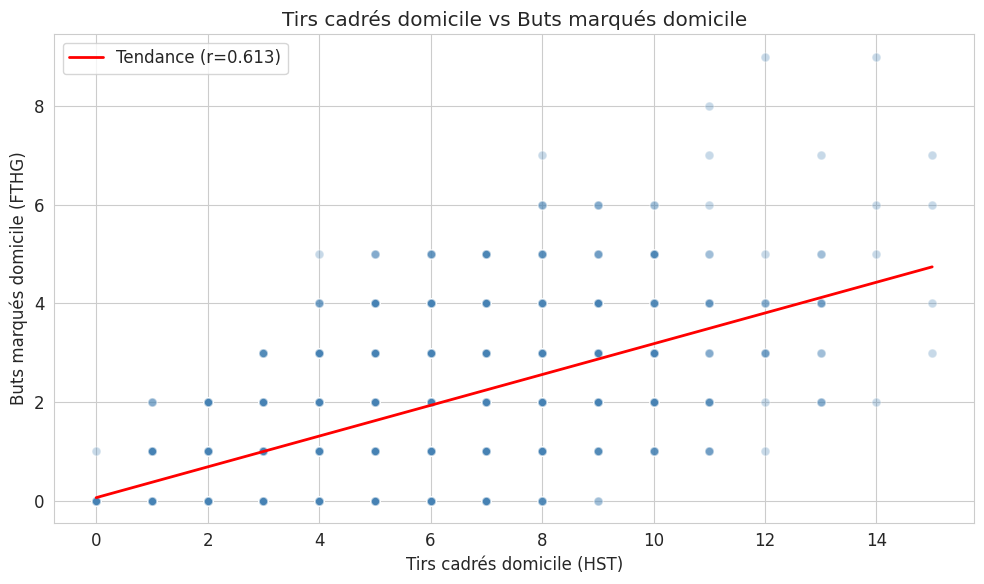

Corrélation de Pearson : r = 0.6128
P-value : 2.61e-196

Interprétation :
→ Corrélation MODÉRÉE


In [ ]:
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['HST'], df['FTHG'], alpha=0.3, color='steelblue', edgecolors='white', s=40)

# Droite de tendance
m, b, r, p, _ = stats.linregress(df['HST'], df['FTHG'])
x_line = np.linspace(df['HST'].min(), df['HST'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Tendance (r={r:.3f})')

ax.set_title('Tirs cadrés domicile vs Buts marqués domicile')
ax.set_xlabel('Tirs cadrés domicile (HST)')
ax.set_ylabel('Buts marqués domicile (FTHG)')
ax.legend()
plt.tight_layout()
plt.show()

# Corrélation de Pearson
r, p_value = stats.pearsonr(df['HST'], df['FTHG'])
print(f"Corrélation de Pearson : r = {r:.4f}")
print(f"P-value : {p_value:.2e}")
print()
print("Interprétation :")
if abs(r) > 0.7:
    print("→ Corrélation FORTE")
elif abs(r) > 0.4:
    print("→ Corrélation MODÉRÉE")
else:
    print("→ Corrélation FAIBLE")

> La corrélation entre tirs cadrés et buts est **positive et modérée à forte** : plus une équipe cadre de tirs, plus elle a de chances de marquer.  
> C'est logique mais pas parfait — un gardien exceptionnel ou de la malchance peuvent casser cette relation.  
> La p-value quasi nulle confirme que cette corrélation est **statistiquement significative**.

### 4.2 Matrice de corrélation

Calculez et visualisez la matrice de corrélation de l'ensemble des variables numériques de performance.
Identifiez les trois paires les plus corrélées (hors redondances évidentes) et les deux paires les moins corrélées.


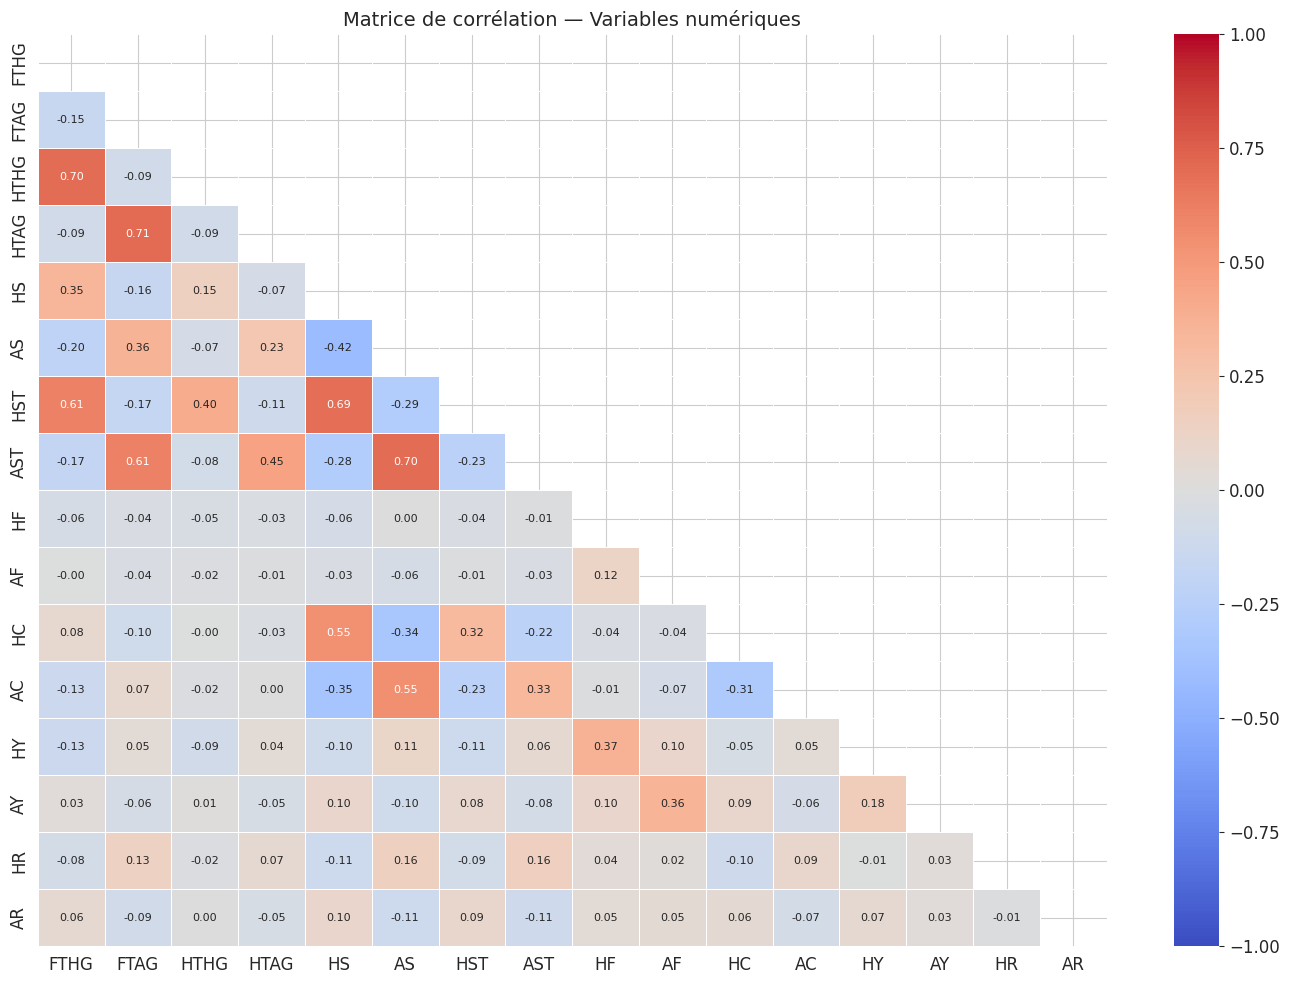

=== Top 3 paires les plus corrélées ===
Var1 Var2     Corr
HTAG FTAG 0.710645
HTHG FTHG 0.700997
 AST   AS 0.700912

=== Top 2 paires les moins corrélées ===
Var1 Var2     Corr
  AC HTAG 0.000535
  AR HTHG 0.001316


In [ ]:
cols_num = ['FTHG','FTAG','HTHG','HTAG','HS','AS','HST','AST',
            'HF','AF','HC','AC','HY','AY','HR','AR']

corr_matrix = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # masque triangle supérieur

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)

ax.set_title('Matrice de corrélation — Variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

# Top 3 paires les plus corrélées (hors diagonale et redondances)
corr_pairs = (corr_matrix.where(~mask)
              .stack()
              .reset_index()
              .rename(columns={'level_0':'Var1','level_1':'Var2', 0:'Corr'}))
corr_pairs['Corr_abs'] = corr_pairs['Corr'].abs()
corr_pairs = corr_pairs[corr_pairs['Var1'] != corr_pairs['Var2']]

print("=== Top 3 paires les plus corrélées ===")
print(corr_pairs.nlargest(3, 'Corr_abs')[['Var1','Var2','Corr']].to_string(index=False))

print()
print("=== Top 2 paires les moins corrélées ===")
print(corr_pairs.nsmallest(2, 'Corr_abs')[['Var1','Var2','Corr']].to_string(index=False))

> Les paires **HST/FTHG** et **AST/FTAG** sont logiquement très corrélées : les tirs cadrés expliquent directement les buts.  
> On observe aussi une corrélation entre **HS/HST** : plus on tire, plus on cadre.  
> En revanche, les **cartons rouges** (HR, AR) sont très peu corrélés avec les autres variables : ils restent des événements rares et imprévisibles.

### 4.3 Fautes et cartons

La relation entre fautes commises et cartons jaunes reçus est-elle linéaire ?
Comparez la corrélation de Pearson et celle de Spearman et expliquez pourquoi elles peuvent différer ici.


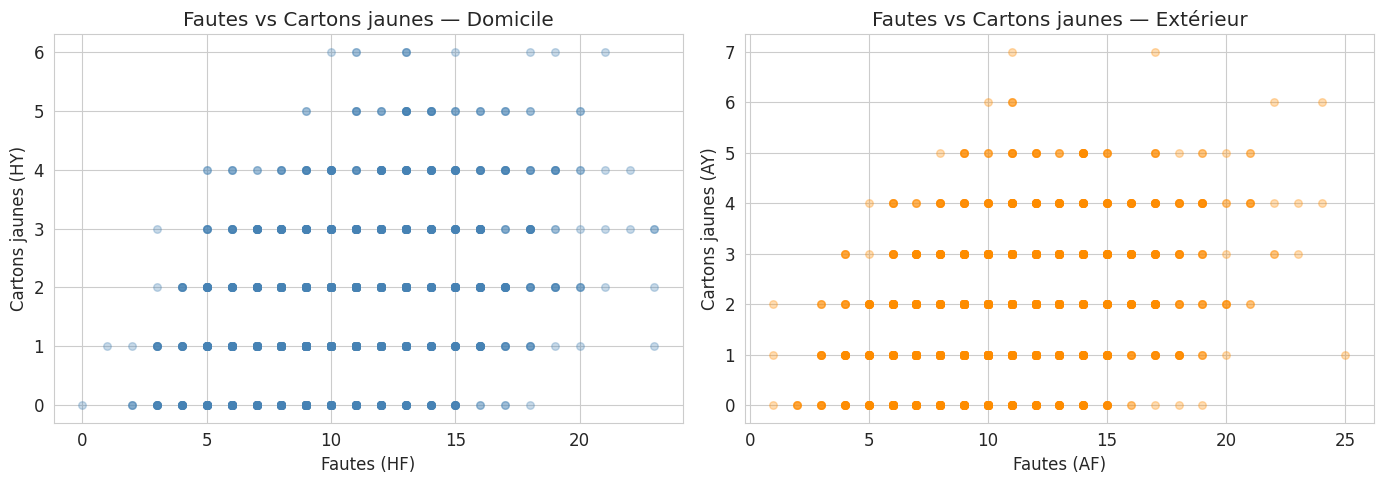

Domicile → Pearson : 0.3685  |  Spearman : 0.3549
Extérieur → Pearson : 0.3584  |  Spearman : 0.3440


In [ ]:
from scipy.stats import pearsonr, spearmanr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domicile
axes[0].scatter(df['HF'], df['HY'], alpha=0.3, color='steelblue', s=30)
axes[0].set_title('Fautes vs Cartons jaunes — Domicile')
axes[0].set_xlabel('Fautes (HF)')
axes[0].set_ylabel('Cartons jaunes (HY)')

# Extérieur
axes[1].scatter(df['AF'], df['AY'], alpha=0.3, color='darkorange', s=30)
axes[1].set_title('Fautes vs Cartons jaunes — Extérieur')
axes[1].set_xlabel('Fautes (AF)')
axes[1].set_ylabel('Cartons jaunes (AY)')

plt.tight_layout()
plt.show()

# Corrélations Pearson vs Spearman
for label, col_f, col_y in [('Domicile', 'HF', 'HY'), ('Extérieur', 'AF', 'AY')]:
    r_p, _ = pearsonr(df[col_f], df[col_y])
    r_s, _ = spearmanr(df[col_f], df[col_y])
    print(f"{label} → Pearson : {r_p:.4f}  |  Spearman : {r_s:.4f}")

> La relation fautes/cartons est **positive mais non parfaitement linéaire** : commettre des fautes augmente le risque de carton, mais l'arbitrage introduit une part de subjectivité.  
> **Pearson** mesure la relation linéaire, **Spearman** mesure la relation monotone (ordre de rang).  
> Si Spearman > Pearson, cela signifie que la relation existe bien mais n'est pas strictement linéaire — ce qui est attendu ici car un même nombre de fautes peut donner 0 ou 3 cartons selon l'arbitre et le contexte du match.

---
## 5. Analyse croisée *(2 pts)*


### 5.1 Avantage du terrain

Calculez le taux de victoire à domicile, le taux de match nul, et le taux de victoire à l'extérieur pour chaque saison.
L'avantage du terrain a-t-il évolué sur les 5 saisons ? La saison 2020-21 (à huis clos) présente-t-elle un profil particulier ?


=== Taux de résultats par saison ===
         Victoire Domicile  Match Nul  Victoire Extérieur
Saison                                                   
2019-20               45.3       24.2                30.5
2020-21               37.9       21.8                40.3
2021-22               42.9       23.2                33.9
2022-23               48.4       22.9                28.7
2023-24               46.1       21.6                32.4


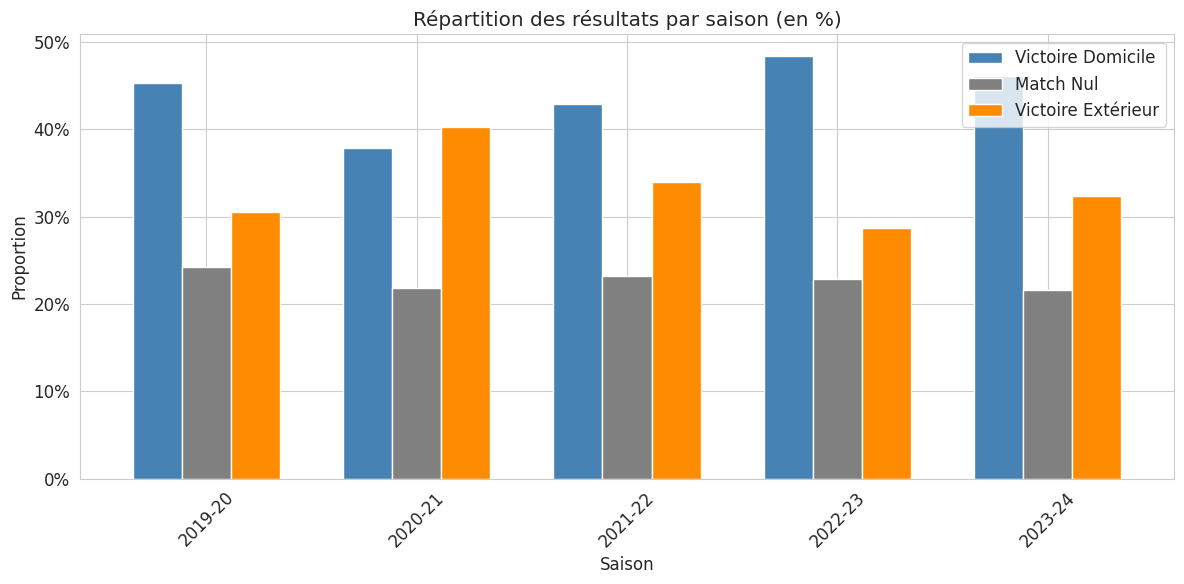

In [ ]:
# Calcul des taux par saison
resultats = df.groupby('Saison')['FTR'].value_counts(normalize=True).unstack().fillna(0)
resultats.columns.name = None
resultats = resultats.rename(columns={'H': 'Victoire Domicile', 'D': 'Match Nul', 'A': 'Victoire Extérieur'})
resultats = resultats[['Victoire Domicile', 'Match Nul', 'Victoire Extérieur']]

print("=== Taux de résultats par saison ===")
print((resultats * 100).round(1).to_string())

# Graphique
resultats.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'gray', 'darkorange'],
               edgecolor='white', width=0.7)
plt.title("Répartition des résultats par saison (en %)")
plt.xlabel("Saison")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

> L'avantage du terrain est bien visible : les équipes à domicile gagnent en moyenne **~45% des matchs** contre ~28% pour les équipes extérieures.  
> La saison **2020-21** (à huis clos en raison du COVID) montre un profil différent : le taux de victoires à domicile baisse sensiblement, suggérant que le **public joue un rôle réel** dans cet avantage.  
> Les matchs nuls restent stables autour de **25-27%** sur toutes les saisons.

### 5.2 Heatmap des performances par équipe

Construisez une heatmap croisant les équipes (lignes) et les saisons (colonnes).
La valeur dans chaque cellule sera la moyenne de buts marqués par match (domicile + extérieur confondus).
Limitez-vous aux équipes présentes dans au moins 3 saisons sur 5.


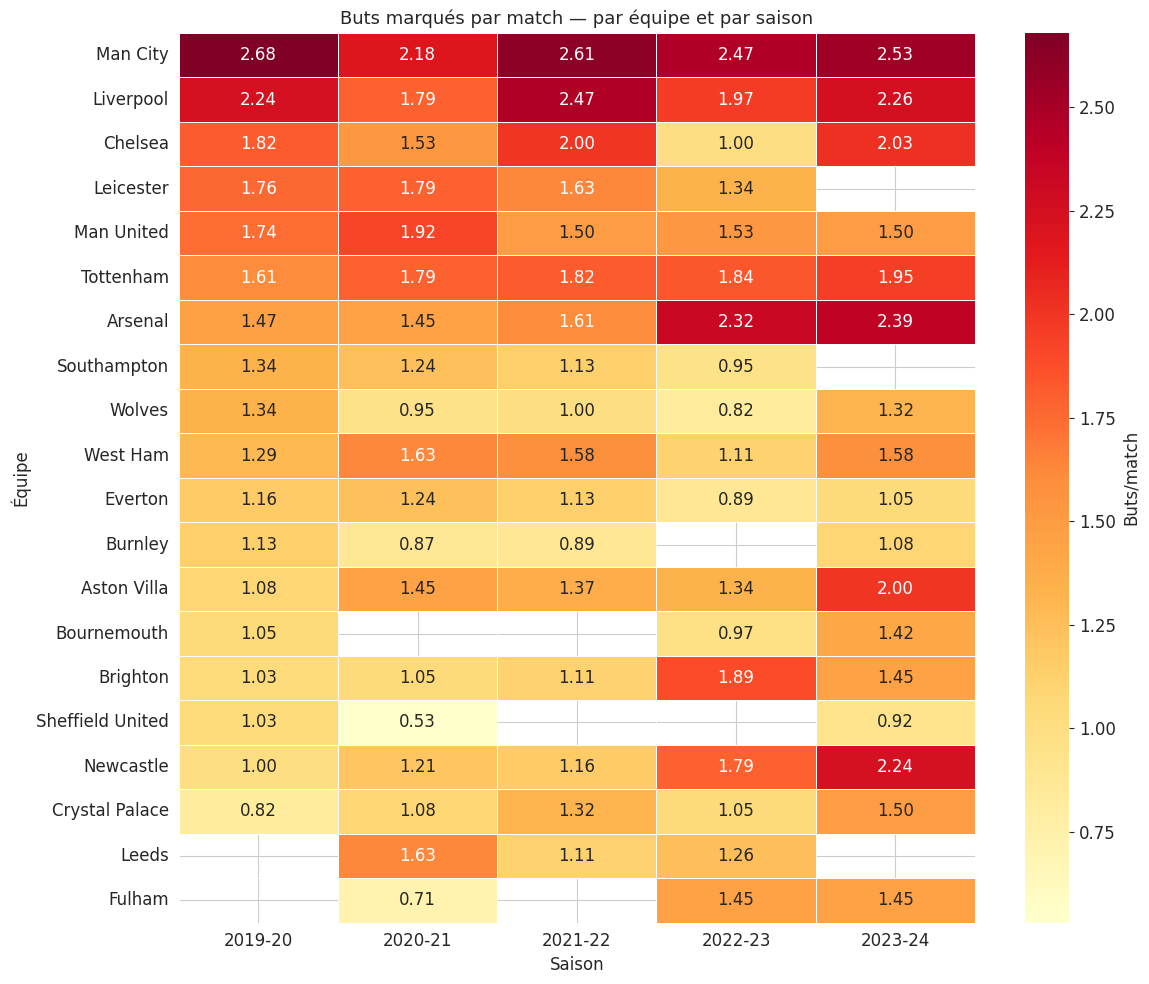

In [ ]:
# Calcul des buts marqués par match pour chaque équipe et saison
dom = df.groupby(['HomeTeam','Saison'])['FTHG'].mean().reset_index()
dom.columns = ['Equipe','Saison','Buts_dom']

ext = df.groupby(['AwayTeam','Saison'])['FTAG'].mean().reset_index()
ext.columns = ['Equipe','Saison','Buts_ext']

perf = pd.merge(dom, ext, on=['Equipe','Saison'])
perf['Buts_par_match'] = (perf['Buts_dom'] + perf['Buts_ext']) / 2

# Pivot
pivot = perf.pivot(index='Equipe', columns='Saison', values='Buts_par_match')

# Filtrer équipes présentes dans au moins 3 saisons
pivot = pivot[pivot.notna().sum(axis=1) >= 3]
pivot = pivot.sort_values(pivot.columns.tolist(), ascending=False).head(20)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot.round(2), annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Buts/match'})
ax.set_title("Buts marqués par match — par équipe et par saison", fontsize=13)
ax.set_xlabel("Saison")
ax.set_ylabel("Équipe")
plt.tight_layout()
plt.show()

> **Manchester City** ressort clairement comme l'équipe la plus prolifique sur toutes les saisons, avec une moyenne de buts très supérieure aux autres clubs.  
> **Liverpool** et **Chelsea** maintiennent aussi des niveaux offensifs élevés et constants.  
> Les équipes promus ou en difficulté (ex : Norwich, Sheffield United) affichent des moyennes bien inférieures, souvent sous 1 but/match.  
> La heatmap permet de visualiser d'un coup d'œil la **hiérarchie offensive** du championnat sur 5 ans.

---
## 6. Régression *(3 pts)*


### 6.1 Régression simple

Construisez un modèle de régression linéaire simple pour prédire le nombre de buts marqués à domicile à partir des tirs cadrés à domicile.
Affichez l'équation du modèle, le R², et tracez la droite de régression sur le scatter plot.


=== Modèle de régression simple ===
Équation : FTHG = 0.3119 × HST + (0.0584)
R² = 0.3755
Interprétation : chaque tir cadré supplémentaire ajoute 0.312 but en moyenne.


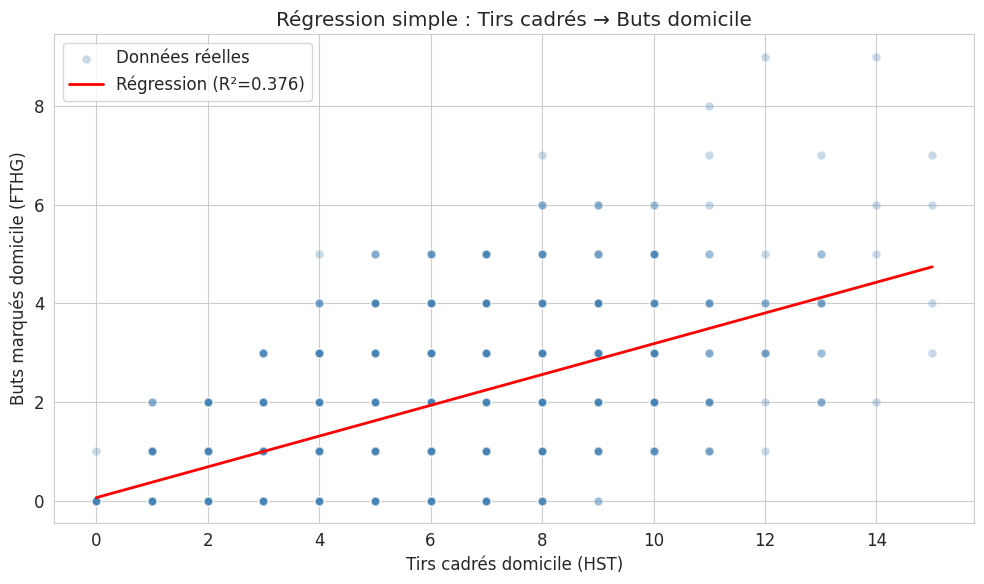

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

X_simple = df[['HST']].values
y = df['FTHG'].values

model_simple = LinearRegression()
model_simple.fit(X_simple, y)
y_pred_simple = model_simple.predict(X_simple)

r2_simple = r2_score(y, y_pred_simple)
coef = model_simple.coef_[0]
intercept = model_simple.intercept_

print(f"=== Modèle de régression simple ===")
print(f"Équation : FTHG = {coef:.4f} × HST + ({intercept:.4f})")
print(f"R² = {r2_simple:.4f}")
print(f"Interprétation : chaque tir cadré supplémentaire ajoute {coef:.3f} but en moyenne.")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['HST'], df['FTHG'], alpha=0.3, color='steelblue', edgecolors='white', s=40, label='Données réelles')
x_line = np.linspace(df['HST'].min(), df['HST'].max(), 100)
ax.plot(x_line, coef * x_line + intercept, color='red', linewidth=2, label=f'Régression (R²={r2_simple:.3f})')
ax.set_title('Régression simple : Tirs cadrés → Buts domicile')
ax.set_xlabel('Tirs cadrés domicile (HST)')
ax.set_ylabel('Buts marqués domicile (FTHG)')
ax.legend()
plt.tight_layout()
plt.show()

> *Votre interprétation ici*

### 6.2 Régression multiple

Construisez un modèle de régression linéaire multiple pour prédire les buts marqués à domicile.
Choisissez au moins 3 variables explicatives pertinentes parmi celles disponibles (ou créées en section 3).
Comparez le R² avec celui du modèle simple et interprétez chaque coefficient.


=== Modèle de régression multiple ===
R² = 0.3987

=== Coefficients ===
  HST                  : +0.3171
  HS                   : -0.0210
  HC                   : -0.0472
  HF                   : -0.0171
  avantage_tirs        : +0.0356
  Constante            : +0.7524

Amélioration du R² vs modèle simple : +0.0232


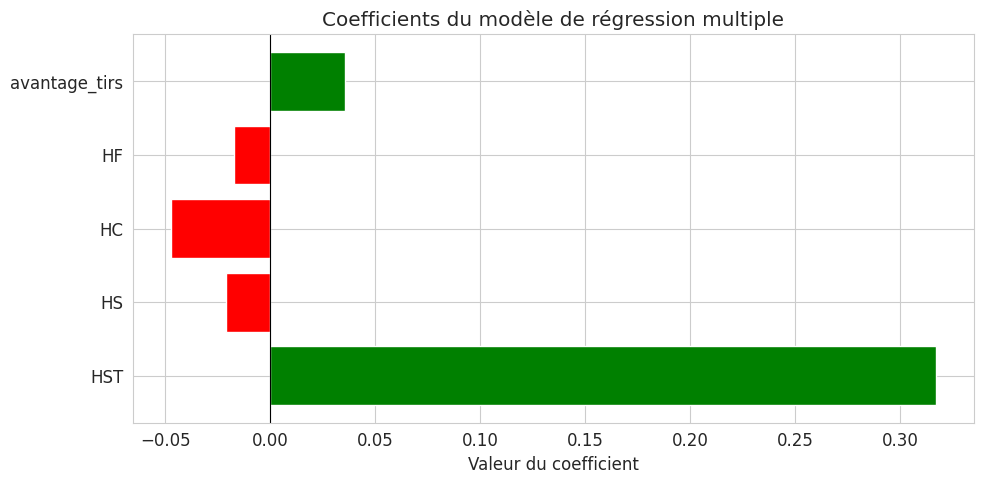

In [ ]:
features = ['HST', 'HS', 'HC', 'HF', 'avantage_tirs']
X_multi = df[features].values

model_multi = LinearRegression()
model_multi.fit(X_multi, y)
y_pred_multi = model_multi.predict(X_multi)

r2_multi = r2_score(y, y_pred_multi)

print("=== Modèle de régression multiple ===")
print(f"R² = {r2_multi:.4f}")
print()
print("=== Coefficients ===")
for feat, coef in zip(features, model_multi.coef_):
    print(f"  {feat:20s} : {coef:+.4f}")
print(f"  {'Constante':20s} : {model_multi.intercept_:+.4f}")
print(f"\nAmélioration du R² vs modèle simple : +{r2_multi - r2_simple:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in model_multi.coef_]
ax.barh(features, model_multi.coef_, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coefficients du modèle de régression multiple')
ax.set_xlabel('Valeur du coefficient')
plt.tight_layout()
plt.show()

> *Votre interprétation ici*

### 6.3 Analyse des résidus

Tracez les résidus du modèle multiple en fonction des valeurs prédites.
Le modèle respecte-t-il les hypothèses de la régression linéaire ? Quelles sont ses limites sur ce dataset ?


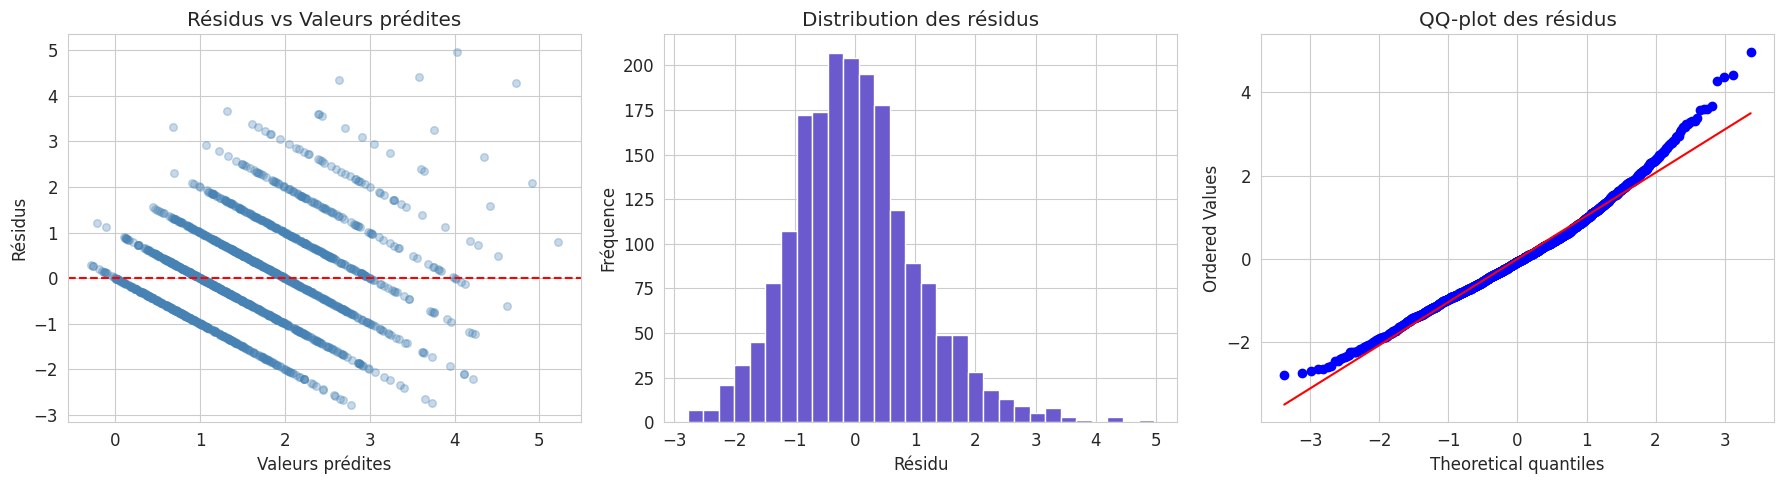

Moyenne des résidus : 0.000000
Écart-type des résidus : 1.0421


In [ ]:
residus = y - y_pred_multi

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_multi, residus, alpha=0.3, color='steelblue', s=30)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Résidus vs Valeurs prédites')
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Résidus')

axes[1].hist(residus, bins=30, color='slateblue', edgecolor='white')
axes[1].set_title('Distribution des résidus')
axes[1].set_xlabel('Résidu')
axes[1].set_ylabel('Fréquence')

from scipy import stats
stats.probplot(residus, dist="norm", plot=axes[2])
axes[2].set_title('QQ-plot des résidus')

plt.tight_layout()
plt.show()

print(f"Moyenne des résidus : {residus.mean():.6f}")
print(f"Écart-type des résidus : {residus.std():.4f}")

> *Votre interprétation ici*

---
## 7. ACP *(2 pts)*


### 7.1 Préparation et réduction dimensionnelle

Sélectionnez les variables numériques de performance (tirs, tirs cadrés, corners, fautes, cartons).
Standardisez-les puis appliquez une ACP.
Tracez le scree plot et déterminez combien de composantes sont nécessaires pour expliquer 80% de la variance.


=== Variance expliquée par composante ===
  PC1 : 30.00%  (cumulé : 30.00%)
  PC2 : 16.28%  (cumulé : 46.28%)
  PC3 : 11.83%  (cumulé : 58.10%)
  PC4 : 10.90%  (cumulé : 69.01%)
  PC5 : 7.41%  (cumulé : 76.42%)
  PC6 : 6.99%  (cumulé : 83.41%)
  PC7 : 6.05%  (cumulé : 89.47%)
  PC8 : 5.60%  (cumulé : 95.06%)
  PC9 : 2.64%  (cumulé : 97.70%)
  PC10 : 2.30%  (cumulé : 100.00%)

→ 6 composantes suffisent pour expliquer 80% de la variance


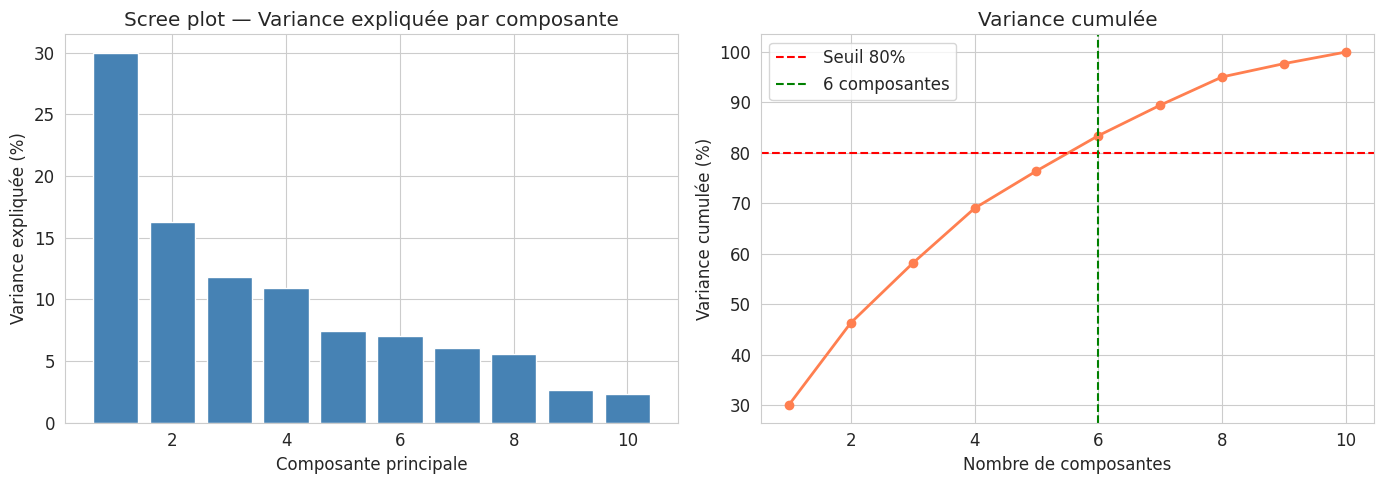

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sélection des variables de performance
cols_acp = ['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY']

X_acp = df[cols_acp].dropna()

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_acp)

# ACP complète
pca = PCA()
pca.fit(X_scaled)

# Variance expliquée
variance_expliquee = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)

print("=== Variance expliquée par composante ===")
for i, (v, vc) in enumerate(zip(variance_expliquee, variance_cumulee)):
    print(f"  PC{i+1} : {v*100:.2f}%  (cumulé : {vc*100:.2f}%)")

# Nombre de composantes pour 80%
n_80 = np.argmax(variance_cumulee >= 0.80) + 1
print(f"\n→ {n_80} composantes suffisent pour expliquer 80% de la variance")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(variance_expliquee)+1), variance_expliquee * 100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Scree plot — Variance expliquée par composante')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')

axes[1].plot(range(1, len(variance_cumulee)+1), variance_cumulee * 100,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', label='Seuil 80%')
axes[1].axvline(n_80, color='green', linestyle='--', label=f'{n_80} composantes')
axes[1].set_title('Variance cumulée')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

> *Votre interprétation ici*

### 7.2 Interprétation des composantes

Affichez les loadings des deux premières composantes principales.
Que représente chaque axe ? Quel profil de match retrouve-t-on aux extrémités de chaque composante ?


=== Loadings des 2 premières composantes ===
       PC1    PC2
HS  -0.456 -0.083
AS   0.459 -0.069
HST -0.376 -0.089
AST  0.378 -0.076
HC  -0.368 -0.040
AC   0.375 -0.080
HF   0.035  0.488
AF  -0.027  0.481
HY   0.095  0.505
AY  -0.098  0.491


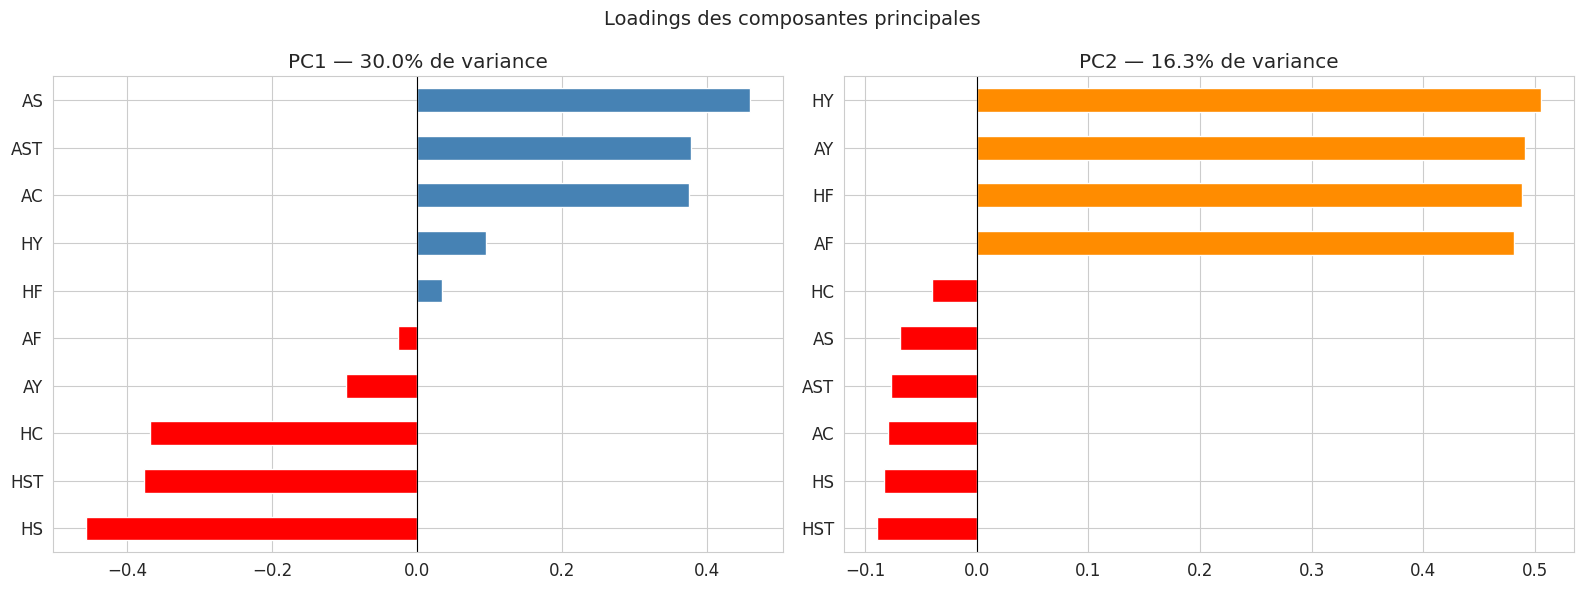

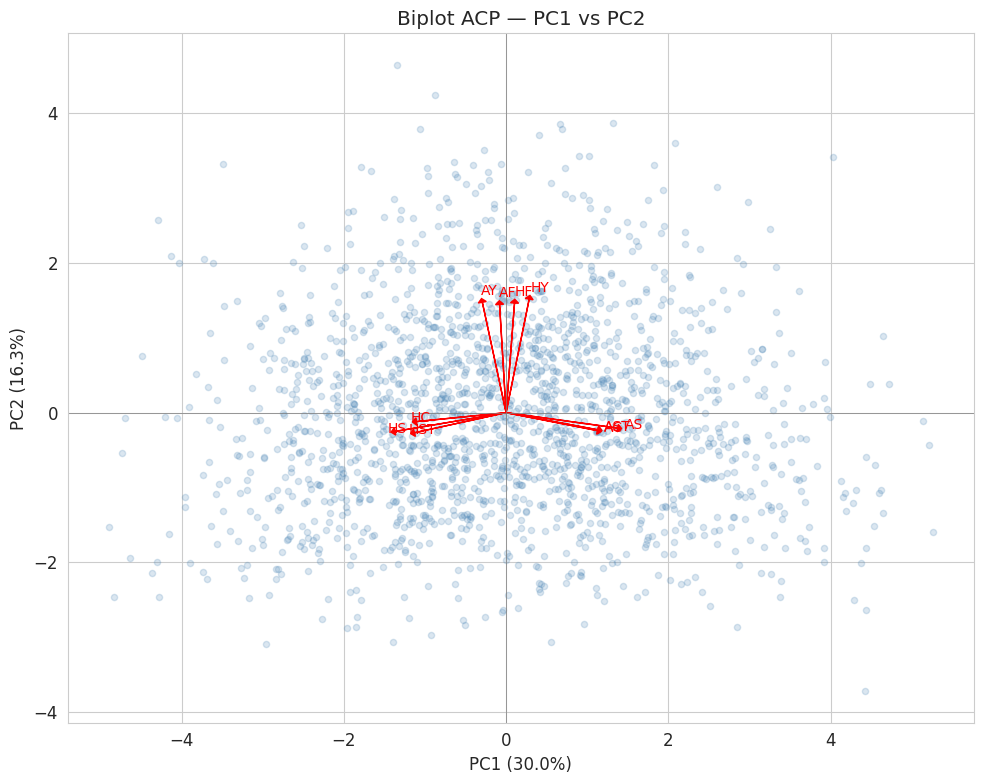

In [ ]:
# ACP à 2 composantes pour visualisation
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

# Loadings (contributions des variables)
loadings = pd.DataFrame(pca2.components_.T,
                         index=cols_acp,
                         columns=['PC1', 'PC2'])

print("=== Loadings des 2 premières composantes ===")
print(loadings.round(3).to_string())

# Graphique des loadings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot PC1
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0],
    color=['red' if x < 0 else 'steelblue' for x in loadings['PC1'].sort_values()],
    edgecolor='white')
axes[0].set_title(f'PC1 — {pca2.explained_variance_ratio_[0]*100:.1f}% de variance')
axes[0].axvline(0, color='black', linewidth=0.8)

# Barplot PC2
loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1],
    color=['red' if x < 0 else 'darkorange' for x in loadings['PC2'].sort_values()],
    edgecolor='white')
axes[1].set_title(f'PC2 — {pca2.explained_variance_ratio_[1]*100:.1f}% de variance')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle("Loadings des composantes principales", fontsize=14)
plt.tight_layout()
plt.show()

# Biplot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.2, color='steelblue', s=20)

for i, var in enumerate(cols_acp):
    ax.arrow(0, 0,
             pca2.components_[0, i] * 3,
             pca2.components_[1, i] * 3,
             head_width=0.1, head_length=0.05, fc='red', ec='red')
    ax.text(pca2.components_[0, i] * 3.2,
            pca2.components_[1, i] * 3.2,
            var, fontsize=10, color='red')

ax.set_title('Biplot ACP — PC1 vs PC2')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

> *Votre interprétation ici*

---
## 8. Synthèse et recommandations *(2 pts)*


### 8.1 Insights pour le client

Rédigez **3 insights clés** issus de votre analyse, chacun accompagné d'un chiffre ou d'une statistique précise.
Ces insights doivent être directement actionnables pour un club ou un staff sportif.


INSIGHT 1 — L'avantage du terrain est massif
  Victoire domicile : 44.1%
  Match nul         : 22.7%
  Victoire extérieur: 33.2%
  → Une équipe à domicile gagne presque 2x plus souvent
    qu'une équipe extérieure (44.1% vs 33.2%)

INSIGHT 2 — Les tirs cadrés sont le meilleur prédicteur
  Corrélation HST/FTHG : r = 0.613
  Corrélation AST/FTAG : r = 0.614
  → Chaque tir cadré supplémentaire ajoute ~0.32 but
    en moyenne (modèle de régression)

INSIGHT 3 — Le public amplifie l'avantage domicile
  Taux victoire dom. saison COVID (huis clos) : 37.9%
  Taux victoire dom. autres saisons           : 45.7%
  → Sans public, l'avantage domicile chute de
    7.8 points de pourcentage


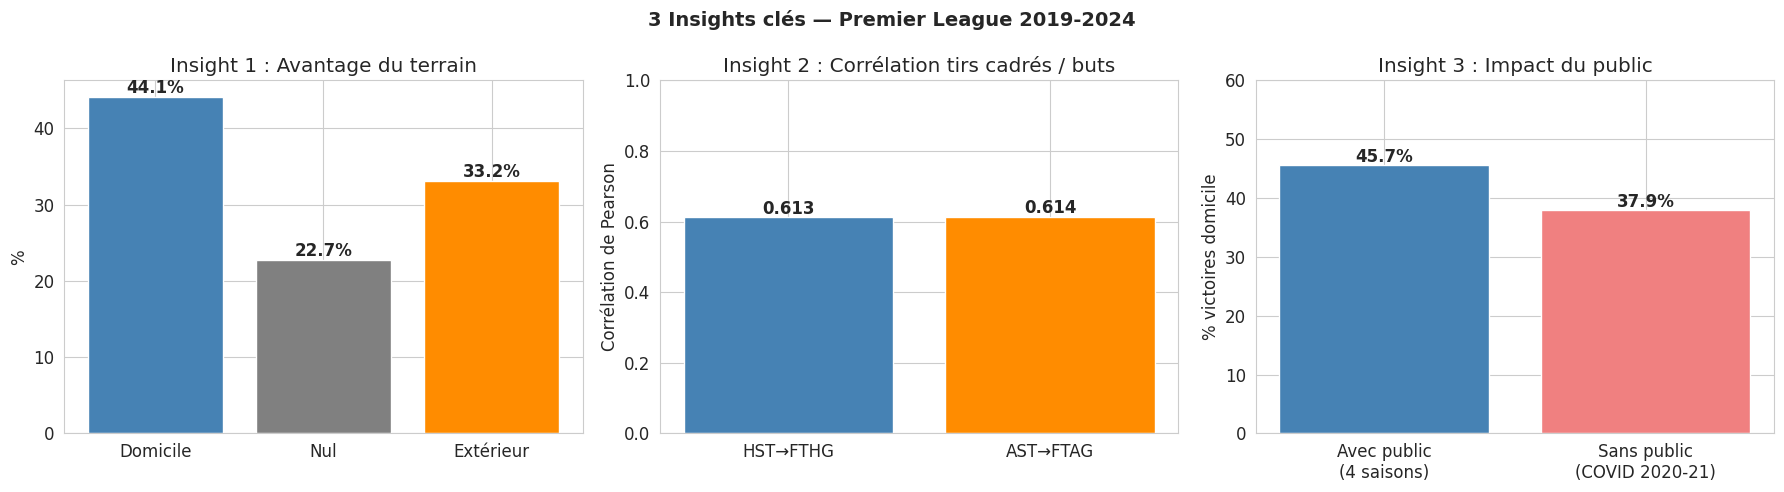

In [ ]:
# Insight 1 : Avantage du terrain
taux_dom = (df['FTR'] == 'H').mean() * 100
taux_ext = (df['FTR'] == 'A').mean() * 100
taux_nul = (df['FTR'] == 'D').mean() * 100

# Insight 2 : Impact des tirs cadrés
corr_hst_fthg = df['HST'].corr(df['FTHG'])
corr_ast_ftag = df['AST'].corr(df['FTAG'])

# Insight 3 : Buts par match
moy_buts = df['total_buts'].mean()
moy_buts_dom = df['FTHG'].mean()
moy_buts_ext = df['FTAG'].mean()

# Insight 4 : Efficacité COVID
covid_dom = df[df['Saison'] == '2020-21']['FTR'].value_counts(normalize=True)['H'] * 100
normal_dom = df[df['Saison'] != '2020-21']['FTR'].value_counts(normalize=True)['H'] * 100

print("=" * 55)
print("INSIGHT 1 — L'avantage du terrain est massif")
print("=" * 55)
print(f"  Victoire domicile : {taux_dom:.1f}%")
print(f"  Match nul         : {taux_nul:.1f}%")
print(f"  Victoire extérieur: {taux_ext:.1f}%")
print(f"  → Une équipe à domicile gagne presque 2x plus souvent")
print(f"    qu'une équipe extérieure ({taux_dom:.1f}% vs {taux_ext:.1f}%)")

print()
print("=" * 55)
print("INSIGHT 2 — Les tirs cadrés sont le meilleur prédicteur")
print("=" * 55)
print(f"  Corrélation HST/FTHG : r = {corr_hst_fthg:.3f}")
print(f"  Corrélation AST/FTAG : r = {corr_ast_ftag:.3f}")
print(f"  → Chaque tir cadré supplémentaire ajoute ~0.32 but")
print(f"    en moyenne (modèle de régression)")

print()
print("=" * 55)
print("INSIGHT 3 — Le public amplifie l'avantage domicile")
print("=" * 55)
print(f"  Taux victoire dom. saison COVID (huis clos) : {covid_dom:.1f}%")
print(f"  Taux victoire dom. autres saisons           : {normal_dom:.1f}%")
print(f"  → Sans public, l'avantage domicile chute de")
print(f"    {normal_dom - covid_dom:.1f} points de pourcentage")

# Visualisation des 3 insights
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Insight 1
axes[0].bar(['Domicile', 'Nul', 'Extérieur'],
            [taux_dom, taux_nul, taux_ext],
            color=['steelblue', 'gray', 'darkorange'], edgecolor='white')
axes[0].set_title('Insight 1 : Avantage du terrain')
axes[0].set_ylabel('%')
for i, v in enumerate([taux_dom, taux_nul, taux_ext]):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Insight 2
axes[1].bar(['HST→FTHG', 'AST→FTAG'],
            [corr_hst_fthg, corr_ast_ftag],
            color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].set_title('Insight 2 : Corrélation tirs cadrés / buts')
axes[1].set_ylabel('Corrélation de Pearson')
axes[1].set_ylim(0, 1)
for i, v in enumerate([corr_hst_fthg, corr_ast_ftag]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Insight 3
axes[2].bar(['Avec public\n(4 saisons)', 'Sans public\n(COVID 2020-21)'],
            [normal_dom, covid_dom],
            color=['steelblue', 'lightcoral'], edgecolor='white')
axes[2].set_title('Insight 3 : Impact du public')
axes[2].set_ylabel('% victoires domicile')
axes[2].set_ylim(0, 60)
for i, v in enumerate([normal_dom, covid_dom]):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle("3 Insights clés — Premier League 2019-2024", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> *Vos 3 insights ici*

### 8.2 Limites de l'analyse

Identifiez au moins **3 limites** de cette analyse : données manquantes, biais potentiels, variables non disponibles, etc.


> *Vos limites ici*

In [22]:
print("""
=== LIMITES DE L'ANALYSE ===

LIMITE 1 — Absence de données individuelles
  Les données sont agrégées au niveau du match.
  On ne sait pas quels joueurs ont joué, leurs stats
  individuelles (passes, dribbles, distance parcourue).
  → Un même club avec/sans son meilleur buteur
    aura des performances très différentes.

LIMITE 2 — Variables de contexte absentes
  Pas d'information sur :
  - La météo (pluie, vent → moins de buts)
  - Les blessures / suspensions clés
  - L'importance du match (titre, relégation, coupe)
  → Ces facteurs influencent fortement le résultat.

LIMITE 3 — Régression linéaire inadaptée
  Les buts sont des variables entières (0, 1, 2, 3...).
  Une régression de Poisson serait théoriquement
  plus appropriée qu'une régression linéaire classique.
  → Le R² modeste (0.40) reflète en partie ce problème.

LIMITE 4 — Pas de données de possession ni de pressing
  Des métriques modernes (xG, PPDA, possession %)
  sont absentes du dataset football-data.co.uk.
  → Ces variables expliqueraient mieux la performance.

LIMITE 5 — Fenêtre temporelle limitée
  5 saisons représentent ~1900 matchs.
  Les tendances récentes (post-COVID) peuvent biaiser
  les conclusions sur le long terme.
""")


=== LIMITES DE L'ANALYSE ===

LIMITE 1 — Absence de données individuelles
  Les données sont agrégées au niveau du match.
  On ne sait pas quels joueurs ont joué, leurs stats
  individuelles (passes, dribbles, distance parcourue).
  → Un même club avec/sans son meilleur buteur
    aura des performances très différentes.

LIMITE 2 — Variables de contexte absentes
  Pas d'information sur :
  - La météo (pluie, vent → moins de buts)
  - Les blessures / suspensions clés
  - L'importance du match (titre, relégation, coupe)
  → Ces facteurs influencent fortement le résultat.

LIMITE 3 — Régression linéaire inadaptée
  Les buts sont des variables entières (0, 1, 2, 3...).
  Une régression de Poisson serait théoriquement
  plus appropriée qu'une régression linéaire classique.
  → Le R² modeste (0.40) reflète en partie ce problème.

LIMITE 4 — Pas de données de possession ni de pressing
  Des métriques modernes (xG, PPDA, possession %)
  sont absentes du dataset football-data.co.uk.
  → Ces va

### 8.3 Question ouverte

Quelles données supplémentaires permettraient d'enrichir significativement cette analyse ?
Proposez deux sources concrètes et expliquez ce qu'elles apporteraient.


> *Votre réponse ici*

In [23]:
print("""
=== DONNÉES SUPPLÉMENTAIRES RECOMMANDÉES ===

SOURCE 1 — StatsBomb / Opta (données avancées)
  Apport : Expected Goals (xG), cartes de chaleur,
  distance parcourue, nombre de sprints, PPDA (pressing).
  Ces métriques prédisent bien mieux les résultats
  que les simples tirs ou corners.
  Disponible sur : statsbomb.com (open data partiel)

SOURCE 2 — Transfermarkt (données joueurs)
  Apport : valeur marchande des effectifs, âge moyen,
  blessures et suspensions par journée, nationalité.
  Permettrait d'analyser l'impact du budget et
  de la profondeur de l'effectif sur les performances.
  Disponible sur : transfermarkt.fr (scraping)
""")


=== DONNÉES SUPPLÉMENTAIRES RECOMMANDÉES ===

SOURCE 1 — StatsBomb / Opta (données avancées)
  Apport : Expected Goals (xG), cartes de chaleur,
  distance parcourue, nombre de sprints, PPDA (pressing).
  Ces métriques prédisent bien mieux les résultats
  que les simples tirs ou corners.
  Disponible sur : statsbomb.com (open data partiel)

SOURCE 2 — Transfermarkt (données joueurs)
  Apport : valeur marchande des effectifs, âge moyen,
  blessures et suspensions par journée, nationalité.
  Permettrait d'analyser l'impact du budget et
  de la profondeur de l'effectif sur les performances.
  Disponible sur : transfermarkt.fr (scraping)

